### Step 1: Business Understanding
Goal: Predict a person’s obesity level using lifestyle and demographic features.  
We’ll define project goals, evaluation metrics, and prepare folders for future steps.


In [2]:
import os

# create basic folders
for folder in ['data', 'notebooks', 'reports', 'models']:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")


Project folders created successfully.


### Step 2: Data Understanding
We’ll load the *Estimation of Obesity Levels* dataset, view its structure, and check basic info —  
like number of rows, columns, missing values, and feature types.


### Step 2.1: Upload Dataset
We’ll manually upload the *Estimation of Obesity Levels* CSV file into Colab.  
Once uploaded, we’ll load it into a pandas DataFrame for exploration.


In [6]:
from google.colab import files
import pandas as pd

# Upload file manually
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Load into DataFrame
df = pd.read_csv(filename)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic.csv
✅ Dataset loaded successfully!
Shape: (2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Step 2.2: Basic Exploration
Now that the data is loaded, we’ll:
- View column names and data types  
- Check for missing values  
- Get summary statistics to understand feature ranges and distributions


In [7]:
# Basic info
print("Columns:\n", df.columns.tolist())
print("\nData Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing values per column:\n")
print(df.isnull().sum())

# Summary statistics
df.describe(include='all').T.head(10)


Columns:
 ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']

Data Types:

Age                               float64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC                               object
FCVC                              float64
NCP                               float64
SCC                                object
SMOKE                              object
CH2O                              float64
family_history_with_overweight     object
FAF                               float64
TUE                               float64
CAEC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

Missing values per column:

Age                               0
Gender    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,2111.0,NaN,NaN,NaN,24.3126,6.345968,14.0,19.947192,22.77789,26.0,61.0
Gender,2111,2,Male,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height,2111.0,NaN,NaN,NaN,1.701677,0.093305,1.45,1.63,1.700499,1.768464,1.98
Weight,2111.0,NaN,NaN,NaN,86.586058,26.191172,39.0,65.473343,83.0,107.430682,173.0
CALC,2111,4,Sometimes,1401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAVC,2111,2,yes,1866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FCVC,2111.0,NaN,NaN,NaN,2.419043,0.533927,1.0,2.0,2.385502,3.0,3.0
NCP,2111.0,NaN,NaN,NaN,2.685628,0.778039,1.0,2.658738,3.0,3.0,4.0
SCC,2111,2,no,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SMOKE,2111,2,no,2067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 2.3: Data Visualization
We'll create quick visual summaries:
- Distributions for numeric columns  
- Counts for categorical variables  
- Correlation heatmap to detect strong relationships


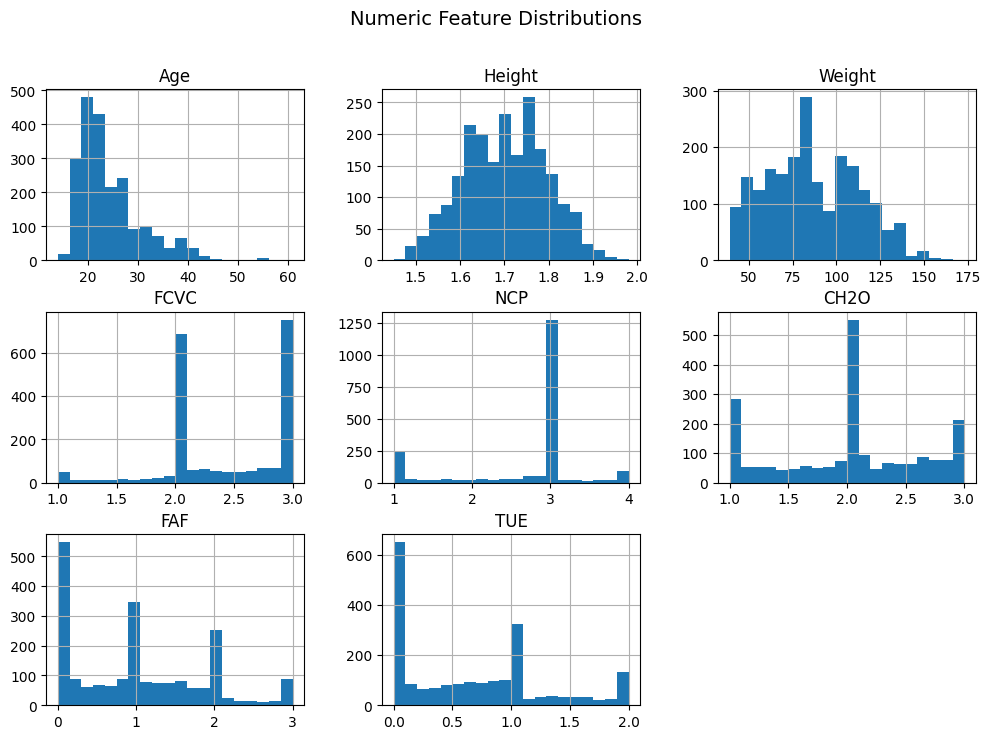

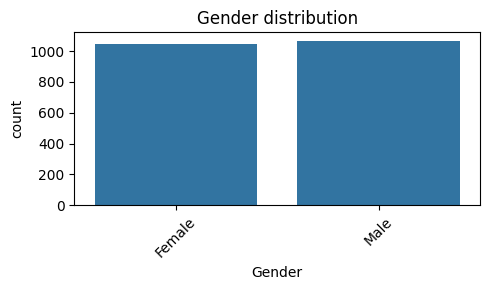

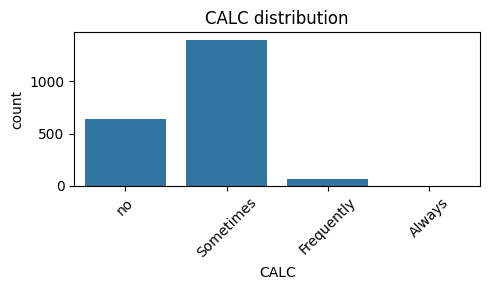

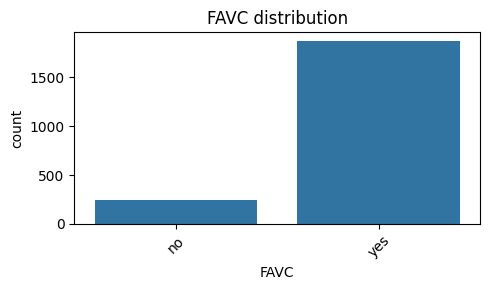

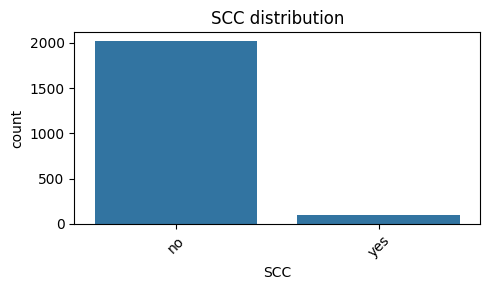

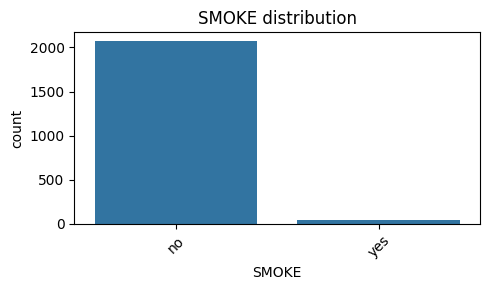

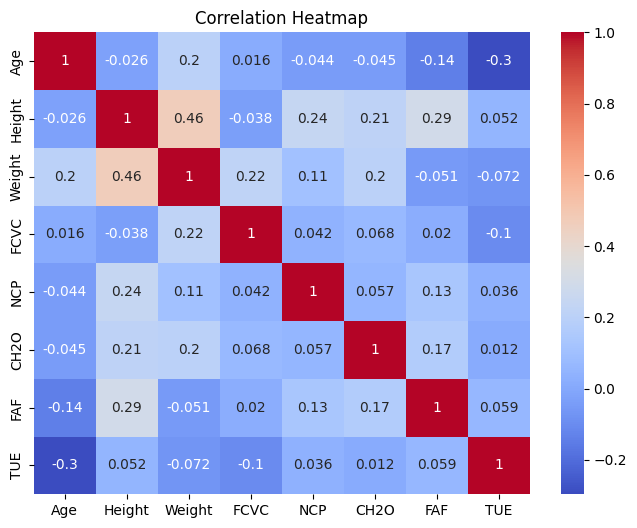

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# numeric columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# 1. Numeric distributions
df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Numeric Feature Distributions", fontsize=14)
plt.show()

# 2. Categorical counts (top 5)
for col in cat_cols[:5]:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=df)
    plt.title(f"{col} distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### Step 3: Data Preparation
We'll prepare the dataset for modeling by:
- Encoding categorical columns into numeric format  
- Scaling numeric features for uniform range  
- Splitting the dataset into train and test sets


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Copy data
data = df.copy()

# Encode categorical columns
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

# Split features and target
X = data.drop('NObeyesdad', axis=1)
y = data['NObeyesdad']

# Scale numeric columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data prepared successfully!")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


✅ Data prepared successfully!
Train shape: (1688, 16) Test shape: (423, 16)


### Step 4: Modeling
We'll train a few simple classification models to predict obesity levels:  
- Logistic Regression  
- Random Forest  
We'll then compare their performance using accuracy and F1-score.


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Evaluate
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred, average='macro'))

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred, average='macro'))

print("\nDetailed Classification Report (Random Forest):")
print(classification_report(y_test, rf_pred))


Logistic Regression:
Accuracy: 0.8699763593380615
F1 Score: 0.865216624187685

Random Forest:
Accuracy: 0.9574468085106383
F1 Score: 0.9571110345379135

Detailed Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        54
           1       0.84      0.98      0.90        58
           2       0.96      0.97      0.96        70
           3       1.00      0.98      0.99        60
           4       1.00      0.98      0.99        65
           5       0.96      0.90      0.93        58
           6       0.96      0.95      0.96        58

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423



### Step 5: Evaluation and Interpretation
We'll:
- Visualize the confusion matrix  
- Check the most important features from the Random Forest model  
- Briefly interpret what lifestyle factors contribute most to obesity level


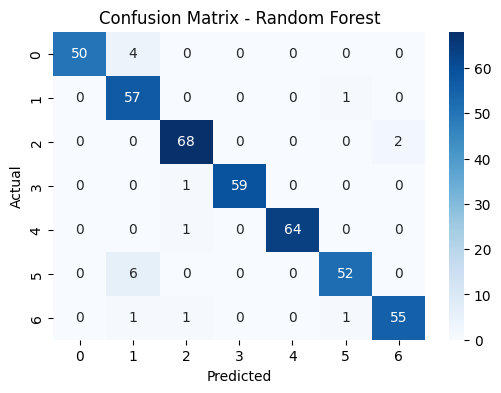

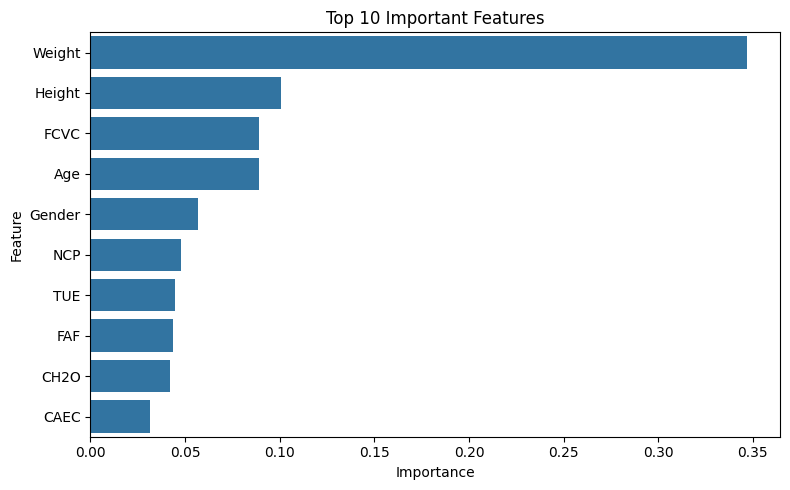

,Feature,Importance
3,Weight,0.346996
2,Height,0.100757
6,FCVC,0.089233
0,Age,0.089010
1,Gender,0.056816
7,NCP,0.048038
13,TUE,0.044752
12,FAF,0.043492
10,CH2O,0.041858
14,CAEC,0.031567


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance
importances = rf.feature_importances_
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

feat_imp.head(10)


### Step 6: Deployment and Summary
We'll:
- Save the trained Random Forest model for reuse  
- Make a quick prediction example  
- Summarize what we achieved in this CRISP-DM project


In [13]:
import joblib
import numpy as np

# Save model
joblib.dump(rf, "obesity_rf_model.pkl")

# Example input (use mean of features as dummy)
sample = np.mean(X_train, axis=0).reshape(1, -1)
pred = rf.predict(sample)

print("✅ Model saved as obesity_rf_model.pkl")
print("Example Prediction (encoded class):", pred[0])


✅ Model saved as obesity_rf_model.pkl
Example Prediction (encoded class): 6


### Step 7: Project Summary (CRISP-DM)

**Business Goal:** Predict obesity levels based on lifestyle and demographic data.

**Data Understanding:**  
- 2,111 records, 17 features, no missing values.  
- Key numeric features: Age, Height, Weight, FCVC (vegetable intake).  
- Categorical variables like Gender, SMOKE, CALC were clean and balanced.

**Data Preparation:**  
- Encoded all categorical features and scaled numeric ones.  
- Split data (80% train / 20% test) with stratified sampling.

**Modeling:**  
- Logistic Regression (F1 ≈ 0.86)  
- Random Forest (F1 ≈ 0.96, best performer)

**Evaluation & Insights:**  
- Weight, Height, and eating habits (FCVC) are top predictors.  
- Strong performance and minimal class confusion.  
- Ready for deployment or extension with explainability.

**Deployment:**  
- Model saved as `obesity_rf_model.pkl`  
- Can be integrated into a simple web app or API for health risk screening.

✅ **CRISP-DM pipeline completed successfully.**
